In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# 1. 普通函数/导数

## 1. 简单的例子

In [2]:
def f(x):
    return 3*x**2-4*x+5

In [3]:
f(3)

20

In [4]:
xs = np.arange(-5,5,0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [5]:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

关于为什么这里 一个接受标量的f(x)可以自动完成向量数组的计算，本质是因为：

NumPy 的 `ndarray` 对象对 Python 的`基本数学运算符（如 +, -, *, /, ** 等）进行了重载`。当你把这些运算符用于 NumPy 数组时，NumPy 不会像处理普通 Python 列表那样报错，而是会自动将这些操作应用到数组的每一个元素上。

在你的函数中，`x**2` 会被自动转换为对数组 x 中的每一个元素求平方。


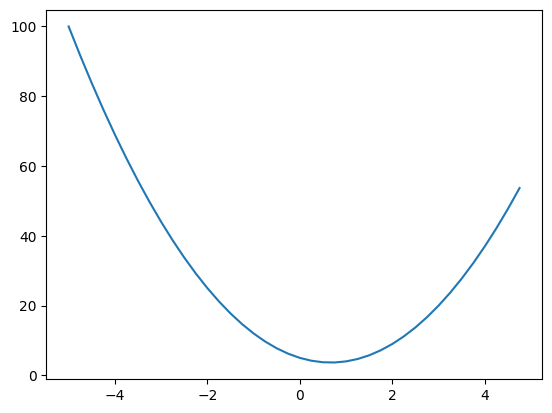

In [6]:
plt.plot(xs,ys)

不能使用微积分里求导的符号化表示，考虑用原始的数值计算

https://en.wikipedia.org/wiki/Derivative

In [7]:
h = 0.001  
x = 3.0
f(x+h)

20.014003000000002

In [8]:
(f(x+h) - f(x))/h  # 函数朝着自变量正向变化的幅度 /该方向的变化量进行归一化处理

14.00300000000243

这种计算得到的只是近似的梯度/斜率值

In [9]:
for level in range(2,18):
    h = 10**(-1*level)
    print(f"level = {h}, slope = {(f(x+h) - f(x))/h}")
print(f"true slope is {6*x-4}")

level = 0.01, slope = 14.029999999999632
level = 0.001, slope = 14.00300000000243
level = 0.0001, slope = 14.000300000063248
level = 1e-05, slope = 14.00003000000538
level = 1e-06, slope = 14.000003002223593
level = 1e-07, slope = 14.000000305713911
level = 1e-08, slope = 14.00000009255109
level = 1e-09, slope = 14.000001158365194
level = 1e-10, slope = 14.000001158365194
level = 1e-11, slope = 14.000178794049134
level = 1e-12, slope = 14.001244608152774
level = 1e-13, slope = 13.997691894473974
level = 1e-14, slope = 14.210854715202004
level = 1e-15, slope = 10.658141036401503
level = 1e-16, slope = 0.0
level = 1e-17, slope = 0.0
true slope is 14.0


可以看到： **数据精度问题**
+ 如果添加过多的0，即：趋近**浮点数表示的边界**，则会因为使用的是浮点数表示，而数据的表示在计算机内存中是有限的
+ 超过这个限制就会引发一定的问题
+ 所以这里在 1e-16的时候就出现计算错误了（甚至可能在更早的 1e-13的时候计算就已经失真了~）
+ 这还是建立在我的电脑默认是 float64的情况下，[CS336——2. PyTorch, resource accounting](https://blog.csdn.net/Castlehe/article/details/155040073)
    + 所以计算结果(中间计算步骤中)一定是超出了 `float64` 的表示范围了

In [10]:
print(type(h))
import sys

# 查看当前系统 float 的详细信息
print(sys.float_info)
# # mant_dig=53 表示尾数有 53 位二进制，加上 1 位隐含位，正好是 64 位 (float64) 的标准

<class 'float'>
sys.float_info(max=1.7976931348623157e+308, max_exp=1024, max_10_exp=308, min=2.2250738585072014e-308, min_exp=-1021, min_10_exp=-307, dig=15, mant_dig=53, epsilon=2.220446049250313e-16, radix=2, rounds=1)


In [11]:
h = 0.01
x = -3
print((f(x+h) - f(x))/h)  # 函数朝着自变量正向变化的幅度 /该方向的变化量进行归一化处理
print(f"true slope is {6*x-4}")

-21.9699999999996
true slope is -22


In [12]:
h = 0.01
x = 2/3
print((f(x+h) - f(x))/h)  # 函数朝着自变量正向变化的幅度 /该方向的变化量进行归一化处理
print(f"true slope is {6*x-4}")  

0.02999999999997449
true slope is 0.0


斜率有正，有负，也有零

## 2. 稍微复杂点的例子

In [13]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [14]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a+=h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h) # d这个函数对于a的导数就是b，即：-3； b同理，c导数为1

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [15]:
d1 = a*b + c
b+=h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h) 

d1 3.999699999999999
d2 3.99990001
slope 2.0001000000124947


In [16]:
d1 = a*b + c
c+=h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)  # 函数值（d）增加的量，刚好等于给c增加的量，即：d对于c的斜率为1， d = c，y=x是条斜线~，斜率为1

d1 3.99990001
d2 4.00000001
slope 0.9999999999976694


# 2. 复杂的多层函数

## 1. 标量计算图（前向传播）构建

一般需要先定义一下数据结构

In [17]:
class Value:
    def __init__(self, data):
        self.data = data
    def __repr__(self):
        """
            当你执行以下操作时，Python 会自动调用对象的 __repr__ 方法：
            1. 调用内置函数 repr(obj)。
            2. 在交互式 Python 解释器（REPL）中直接输入变量名并回车。
            3. 当对象被包含在容器（如列表 list、字典 dict、元组 tuple）中并被打印时（这是最容易踩坑的地方，容器会强制调用内部元素的 __repr__ 而不是 __str__）。
        开发者 (用于调试、日志)
            如果没有定义 __repr__，会显示默认内存地址（如 <__main__.MyClass object at 0x...>）
        """
        return f"Value(data={self.data})"

a = Value(2.0)
a

Value(data=2.0)

### U1-加减乘除重载
**✅Update 1: 除了可以表示数据，还需要这个数据有能够在其上执行的操作**，比如：加减乘除

In [18]:
class Value:
    def __init__(self, data):
        self.data = data
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        """
        运算符重载”（Operator Overloading)
        在 Python 中，运算符重载是通过定义类中的特殊方法（魔术方法 / Dunder Methods） 来实现的。__add__ 方法专门用于重载加法运算符 +。
        """
        out = Value(self.data + other.data)
        return out
    def __mul__(self,other):
        """
        运算符重载”（Operator Overloading)
        在 Python 中，运算符重载是通过定义类中的特殊方法（魔术方法 / Dunder Methods） 来实现的。__add__ 方法专门用于重载加法运算符 +。
        """
        out = Value(self.data * other.data)
        return out

In [19]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)

print(a*b + c) # 自动调用，内部执行的具体过程就下面这个
print((a.__mul__(b)).__add__(c))

Value(data=4.0)
Value(data=4.0)


可以看到，现在已经和之前直接浮点数运算结果一样了。。。

### U2-记录值是哪两个值二元操作的结果
**✅Update 2: 数据结构+操作定义好之后，为了保证能够复现/保留计算图（即：计算顺序）**，
+ 需要维护哪些值生成了其他值的指针（即a→b，则b就是a的子节点）
+ 其实就是`记录当前值的直接来自于哪些值`

这个时候，其实就已经很接近：<https://github.com/karpathy/micrograd/blob/master/micrograd/engine.py> 这里的完整实现了

In [20]:
class Value:
    def __init__(self, data, _children = ()):
        """
        为了表示子节点，引入_children，默认情况是空的元组
        """
        self.data = data
        self._prev = set(_children)  # 这里为了效率，直接把前置集合设置成set(_children) 
        # 注意，这里的children和prev[ious] ，
        # 前者应该是从函数构成角度来讲，其余都是因变量的自变量；
        # 后者是从计算图的流通顺序来说，自变量都是因变量之前的节点
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        out = Value(self.data + other.data, (self, other)) # 当执行操作时，就需要记录操作顺序（把操作节点传进去）
        return out
    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other))
        return out

In [21]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c
d

Value(data=4.0)

In [22]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

### U3-记录值来自什么操作
**✅Update 3: 现在有了每个计算节点的值，还需要知道是哪个操作生成了这个值**

In [23]:
class Value:
    def __init__(self, data, _children = (), _op=''):
        """
        为了表示操作，这里也定义一个op字符串来表示操作，对于单个Value来说，它的来源一定是被分解成基本运算的一步，所以操作只会是单个字符串
        """
        self.data = data
        self._prev = set(_children)  
        self._op = _op
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), '+') # 当执行操作时，就需要记录操作顺序（把操作节点传进去）
        return out
    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [24]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c
print(d)
d._prev, d._op

Value(data=4.0)


({Value(data=-6.0), Value(data=10.0)}, '+')

帮助进行计算图的可视化代码：

In [25]:
!pip install graphviz


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [26]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        # dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        dot.node(name=str(id(n)), label = "{ data %.4f}" % (n.data), shape='record')
        # 创造了 * + 这样的伪节点，以及对应的连接
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

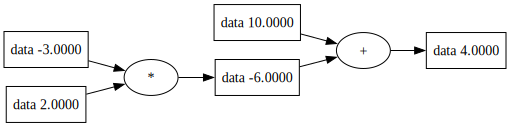

In [27]:
draw_dot(d)

### U4-加个标签（变量名）
**✅Update 4: 给每个数据再加个标签，这样看起来会更容易**

In [28]:
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        """
        这个label其实就是给每个Value对象起个名字
        """
        self.data = data
        self._prev = set(_children)  
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), '+') # 当执行操作时，就需要记录操作顺序（把操作节点传进去）
        return out
    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [29]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s|data %.4f}" % (n.label, n.data), shape='record')
        # 创造了 * + 这样的伪节点，以及对应的连接
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

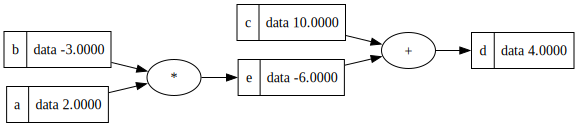

In [30]:
a = Value(2.0,label='a')  
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e = a*b
e.label = 'e'
d = e + c
d.label = 'd'
draw_dot(d)

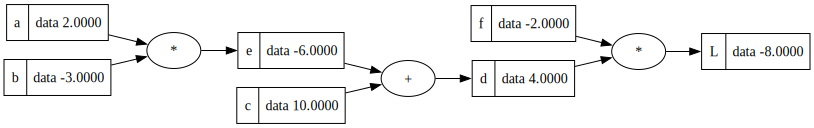

In [31]:
# 也可以更复杂一点

a = Value(2.0,label='a')  
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e = a*b
e.label = 'e'
d = e + c
d.label = 'd'
f = Value(-2, label='f')
L = d*f
L.label='L'
draw_dot(L)

这就是标量前向传播的可视化过程，前向就是计算所有操作的值，最后得到结果值

In [35]:
def f(x):
    return Value(3,label='w1')*x+Value(5,label='w2')

In [38]:
L = f(Value(4, label = 'x1'))

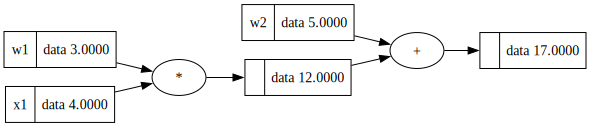

In [39]:
draw_dot(L)

如果换成这种包含自变量的正儿八经的函数表示，可以看到，这些节点里，就包括数据节点，权重节点了~

注意，这里的区别在于，正常情况下，
```python
def f(x):
    return Value(3)*x*Value(2)+Value(4)*x+Value(5)
```

上式中，一般 `x`和`f(x)`是已知的， `w1`, `w2`这种才是未知的，这个例子举的不太好,所以`w1`和`w2`是需要确定的权重
+ 所以关注的是最后的输出对于中间某些叶节点（权重节点，即神经网络的权重）的导数，这些权重会根据梯度信息进行更新
+ 而最后的输出对于其他叶节点（即：数据本身）的导数，则不需要考虑，因为单条数据不会发生改变，是固定的

## 2. 标量反向传播

### U5-记录导数
*Update 5: 在Value中添加一个变量，用来保存损失函数L对该值的导数**

In [2]:
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        """
        这个label其实就是给每个Value对象起个名字
        """
        self.data = data
        self.grad = 0   # 初始梯度都设置为0， 梯度=0表示没有影响~
        self._prev = set(_children)  
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), '+') # 当执行操作时，就需要记录操作顺序（把操作节点传进去）
        return out
    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [1]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s|data %.4f|grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        # 创造了 * + 这样的伪节点，以及对应的连接
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

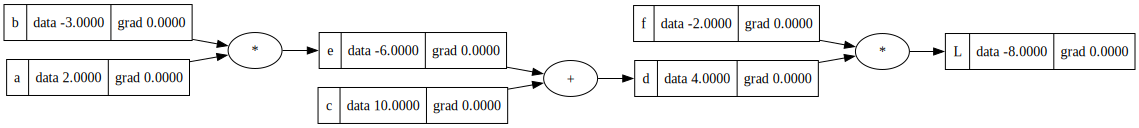

In [43]:
a = Value(2.0,label='a')  
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e = a*b
e.label = 'e'
d = e + c
d.label = 'd'
f = Value(-2, label='f')
L = d*f
L.label='L'
draw_dot(L)

接下来进行反向传播，需要从L损失函数开始逐个计算对每个节点的导数，很明显， L对L的导数就是1

完整计算式子是： L = (a*b+c)*f

In [60]:
def lol():
    """
    临时计算每个变量的导数
    """
    # 计算a的，就给a的数值加上h
    h = 0.0001
    
    a = Value(2.0,label='a')  
    b = Value(-3.0,label='b')
    c = Value(10.0,label='c')
    e = a*b
    e.label = 'e'
    d = e + c
    d.label = 'd'
    f = Value(-2, label='f')
    L = d*f
    L.label='L'
    L1 = L.data

    a = Value(2.0,label='a')  
    b = Value(-3.0 + h,label='b')
    c = Value(10.0,label='c')
    e = a*b
    e.label = 'e'
    d = e + c
    d.label = 'd'
    f = Value(-2, label='f')
    L = d*f
    L.label='L'
    L2 = L.data

    print((L2-L1)/h)
lol()

-4.000000000008441


使用上面的函数，手动计算损失函数L对每个节点的导数

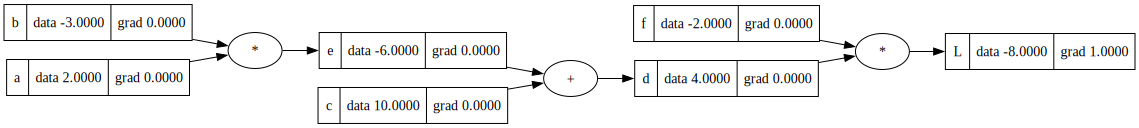

In [50]:
L.grad = 1.0
draw_dot(L)

然后先看 L对f和d的导数，很明显，dL/df = d; dL/dd = f

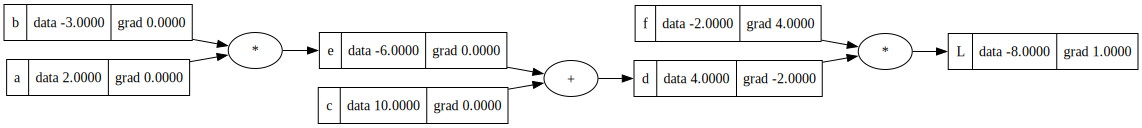

In [51]:
f.grad = 4
d.grad = -2  # 这个导数可以用 lol函数再验证一下,这个验证过程，就类似于一种内联的梯度检验
draw_dot(L)

内联的梯度检验(inline gradient check)
+ 通过反向传播等方式计算中间所有过程的导数，并最终计算出梯度后，进行的一种验证过程
+ 数值梯度(numerical gradient): 通过使用微小步长来估计梯度

接下来，计算  L 对e和c的梯度，

dL/dd = -2， 
 
dd/de = 1 根据 (f(x+h)-f(x))/h →  (e+h+c -(e+c))/h = h/h = 1

dd/dc = 1 

dL/de = (dL/dd)*(dd/de) = -2, dL/dc同理。→  所以可以认为，**加法节点只是简单的将反向传播过程的上一个数据节点的梯度复制**

根据 <https://en.wikipedia.org/wiki/Chain_rule>, 

至此，其实就可以知道，
1. 进行加法操作的两个节点（比如 e和c），`局部梯度都是1`,而这两个节点的`全局梯度`，是`加法的结果变量`的梯度，即：只是一个梯度的分配器；
2. 进行乘法操作的两个节点，局部梯度是进行操作的另一个对象的值，全局梯度就是局部乘以 乘法操作结果变量的梯度

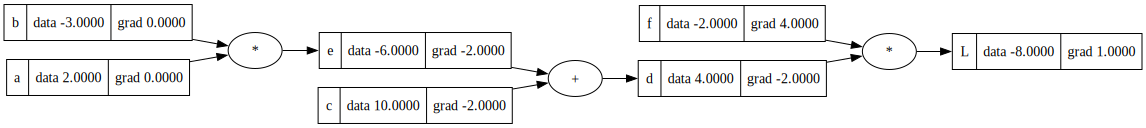

In [57]:
c.grad = d.grad
e.grad = d.grad  # 这个导数可以用 lol函数再验证一下,这个验证过程，就类似于一种内联的梯度检验
draw_dot(L)

继续计算 

dL/da = (dL/de)*(de/da)=(dL/de)*b   

e = a*b

de/da = ((a+h)\*b - a*b)/h = b

dL/db 同理，由此可以看出，**乘法节点就是交换两个操作数的值作为梯度**

同样，也可以用 lol 函数来进行数值梯度的计算，来进行验证

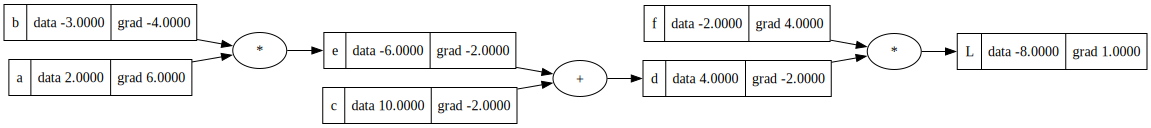

In [58]:
a.grad = e.grad*b.data
b.grad = e.grad*a.data
draw_dot(L)

通过调整输入，来影响 L

In [65]:
a = Value(2.0,label='a')  
b = Value(-3.0,label='b')
c = Value(10.0,label='c')

# a.data +=0.01*a.grad
b.data +=0.01*b.grad
# c.data +=0.01*c.grad
# f.data +=0.01*f.grad

e = a*b; e.label = 'e'
d = e+c; d.label = 'd'
L = d*f
print(L)

Value(data=-7.84)


> 可以看到:<br/>
> L的数值从 -8增加到了 -7.2，<br/>
> dL/db = -4, 说明随着b增大，L会减小；所以**对于b来说，沿着梯度方向**，b其实是在减小→ **L增加** <br/>
> 上述四个变量，不管单独改变哪个，只要是沿着梯度方向，都是 L增加的方向<br/>
> 数学说明详见： [梯度变化的数学解释](https://blog.csdn.net/Castlehe/article/details/161984038)

自变量朝着梯度方向变化，因变量就会增大；

根据这点，就可以来通过梯度控制自变量（即神经网络的权重），进而影响因变量（即损失函数），实现对神经网络的参数更新/训练

# 3. 更复杂的例子（多层感知机）

直接搜索 cs231n neuron

<img src="https://cs231n.github.io/assets/nn1/neuron_model.jpeg" width=40%>
<img src="https://cs231n.github.io/assets/nn1/neural_net2.jpeg" width=40%>

这里会以tanh为例，作为激活函数

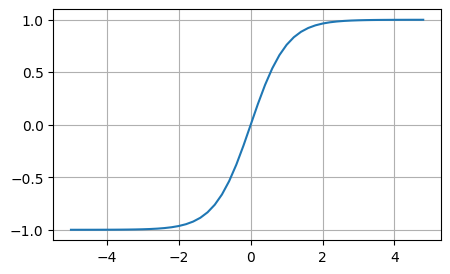

In [7]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(-5,5,0.2)
y = np.tanh(x)
plt.figure(figsize=(5,3))
plt.plot(x,y);plt.grid()

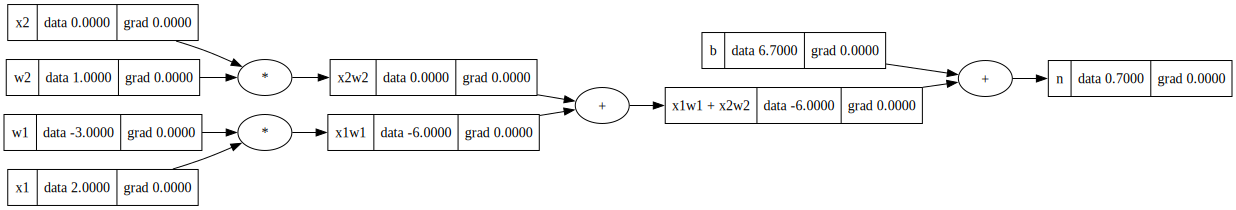

In [3]:
# 一个二维神经元 ，一个神经元，接受的输入是 1x2d的

# inputs，固定数值，不会变，没必要对这个数求梯度，
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

# weights，需要变化的，会依据这个的梯度来影响最终的n，需要求梯度
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias 偏置项
b = Value(6.7, label = 'b')

# 前向计算过程，把整个过程拆解成原子操作，就可以为所有的中间节点建立引用关系，在此基础上求解所有的梯度了
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
draw_dot(n)

上述还没有加入tanh激活函数，需要在 Value 中实现相关操作

## U6- 添加tanh实现（手动计算梯度回传）

https://en.wikipedia.org/wiki/Hyperbolic_functions#Tanh

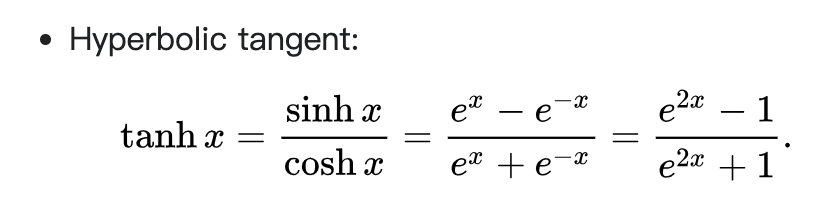


在Value的操作实现中，并不是一定要实现最基础的原子级运算单元，可以在任意抽象层次创建函数。比如：

对于tanh，可以创建指数函数，再去用加法和乘法构建tanh的公式；也可以直接创建tanh这个函数实现。

只要你知道，怎么对这个操作求导（获取局部导数）即可，类似上面的加法和乘法~

In [2]:
import math
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        self.data = data
        self.grad = 0  
        self._prev = set(_children)  
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), '+') 
        return out
    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other), '*')
        return out
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self,), 'tanh')
        return out

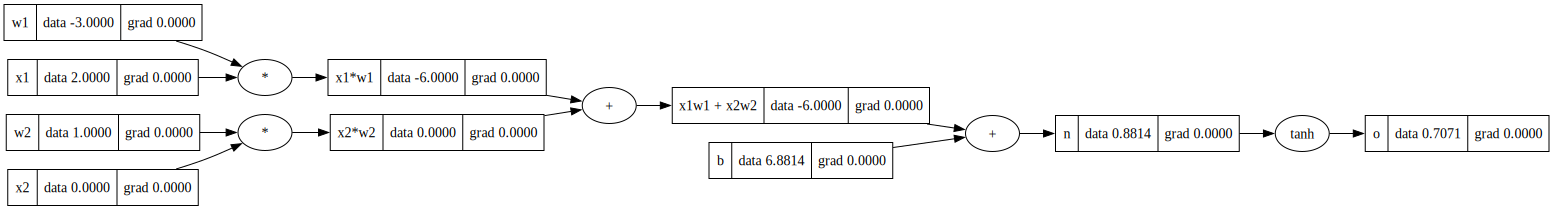

In [7]:
from a_utils import draw_dot
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b')
# 这里b设置这个奇怪的值，是为了保证后续反向传播的时候，出现的值会比较规整，不会有奇奇怪怪的值
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
# x1w1x2w2 = x1*w1 + x2*w2; # 注意，这里不能再用乘法来表示，必须用上面定义过的变量来表示，不然
# 在类似 micrograd 的库中，x1 * w1 每次都会创建一个全新的对象。如果你在设置 label 之后，又不小心重新执行了乘法，新对象会覆盖旧对象，label 就丢失了。
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'
draw_dot(o)

当 `b = Value(6.7, label = 'b')`时

可以看到， o的值和n的值差不多，`o.data = 0.6044`, `n.data = 0.7`, 即：tanh发挥的压缩效果不明显，这是因为输入（n）的值比较小，可以看看 上面tanh的图

当 `b = Value(8, label = 'b')`时

n的值就是 2.0， 即tanh的输入变大了，此时 o.data = 0.964，这时候压缩率就达到了1倍，同时此时，已经到达了tanh函数的尾部，n的值再大，o的值也只会趋于1

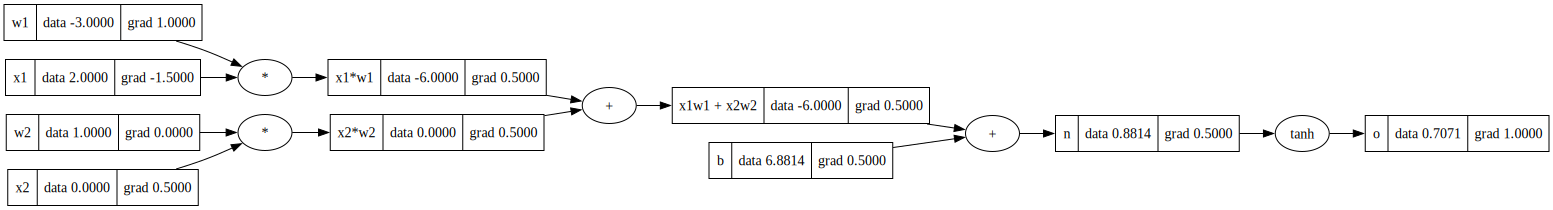

In [8]:
o.grad = 1.0

n.grad = 1 - o.data**2
b.grad = 1 - o.data**2

x1w1x2w2.grad = 1 - o.data**2

x1w1.grad = 1 - o.data**2
x2w2.grad = 1 - o.data**2

w1.grad = x1.data * x1w1.grad
x1.grad = w1.data * x1w1.grad
w2.grad = x2.data * x2w2.grad
x2.grad = w2.data * x2w2.grad

draw_dot(o)

上图中每个变量的grad，即全局梯度，反应的是这个变量调整会如何影响最终的结果，而不是下一步的结果
+ 以 w2 为例，由于会与x2相乘，而x2 = 0， 因此不管 w2如何变化，对最终的结果 o都不会有影响
+ 就好像计算一个公式，0项总是会被直接pass一样

对于上面这个例子；
+ 可以改变的权重只有 w1和w2， 而w2.grad = 0, 无影响
+ 因此能起作用的只有 w1, 即 w1 += 0.01*w1.grad → o就会增大

**do/dn**
o = tanh(n)

do/dh = 1 -tanh(n)**2 # wiki 页面下拉就有  https://en.wikipedia.org/wiki/Hyperbolic_functions#Derivatives

又有 o = tanh(h)

→ do/dh = 1-o**2

**do/db and do/dx1w1x2w2**

do/db = do/dn * dn/db = do/dn 
dn/db = ((b+h + x1w1+x2w2) - (b + x1w1+x2w2))/h = 1

**dx1w1x2w2/dx1w1 and dx1w1x2w2/dx2w2**

同理，加法节点对应的二元数的局部梯度是1，全局梯度是传递加法结果变量的梯度


# 4. 自动反向梯度计算

## u7-添加自动反向梯度实现（手动调用）

In [1]:
import math
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        self.data = data
        self.grad = 0  
        self._backward = lambda:None  # 这里是个函数，默认是空，什么都不做，对于叶节点来说，确实是什么都不做
        # 存储对于一个计算op节点(比如，乘法加法操作)，在反向传播过程中将输出梯度链式传递到输入梯度的逻辑 
        self._prev = set(_children)  
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            """这里定义调用 out.grad 时需要执行的操作
            对于加法操作，out = self.data + other.data
            所以这里的目标就是 把 out.grad 传给 self.grad 和 other.grad
            dout/dself=1, 即self.grad 和 other.grad的局部梯度是1， 
            全局梯度就取决于out.grad（即最终表达式对于out的梯度）
            """
            self.grad = 1.0*out.grad
            other.grad = self.grad
        out._backward = _backward 
        # 注意，这里不是 out._backward = _backward() 
        # 因为只需要存储函数名，而不是执行
        # out也是Value类型，相当于对out的 self._backward进行赋值
        # 这个不会自动执行，而是需要我们执行完加法操作后手动调用来完成梯度传播
        return out
        
    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward =  _backward   # 和add操作里的一样
        return out
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        # 这里其实就是 t = tanh(x) 即 dt/dx = 1-x**2
        # 注意，实际使用的时候不一定tanh是最后一步，因此，这里不能直接乘以1，而依然需要用 Out.grad来承接反向传播上一步的梯度
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad = (1 - t**2)*out.grad
        out._backward = _backward
        return out

In [3]:
from a_utils import draw_dot
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

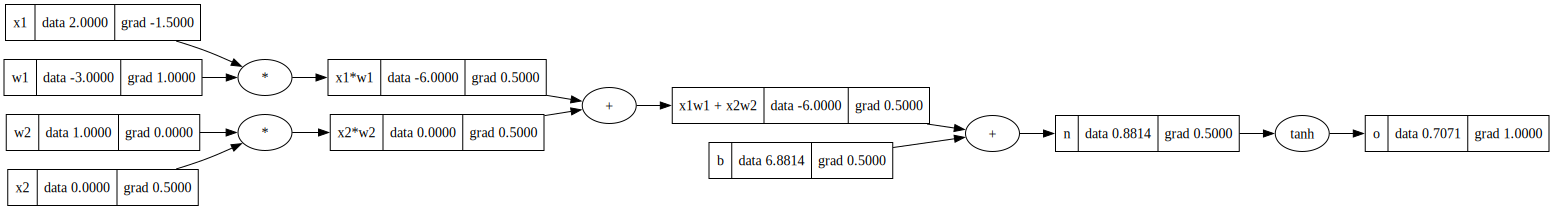

In [11]:
# 可以注释掉，一个一个backward看看效果，最后验证下是不是和上面自己算的结果一样
o.grad = 1
o._backward()
# 注意，o = n.tanh(); 所以o是tanh操作时生成的，o是上面tanh函数里的out，在正向计算的时候，就设置了o._backward = _backward（tanh里的)
# 由于对o执行_backward时, 此时 o.grad没有被赋值过，还是默认的0，所以会导致 计算 self.grad, 即n.grad的时候直接 = (1 - t**2)*o.grad = 0
# 因此，需要提前对 o.grad赋值为1， 才会向n传递正确的梯度
n._backward()
# b._backward()
# 由于b是一个叶节点（没有任何子节点），即：不是通过其他自变量获取的（不是通过对某些自变量执行加减乘除操作得到的）
# 因此，_backward没有被赋值，只是默认的空函数，因此执行不会产生任何影响
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
draw_dot(o)

> 一般认为，在前向计算时，必须完成某个节点后面所有的计算，才能对该节点进行反向传播调用<br/>
> 但是也不是必须的，如果你的整个计算链条里没有乘法或者tanh这样会用到中间节点的值的操作，即：不会用到 ?.data,比如：w1.data<br/>
> 但是上面这种情况基本不会发生，成熟的大型神经网络里都是有乘法（全连接层的）

## 拓扑排序（自动梯度计算调用）

topological sort: 对有向无环图(DAG-  directed acyclic graph)排序，使得所有边的方向只能从左到右
> In computer science, a topological sort or topological ordering of a directed graph is a linear ordering of its vertices such that for every directed edge (u,v) from vertex u to vertex v, u comes before v in the ordering.

<https://en.wikipedia.org/wiki/Topological_sorting>

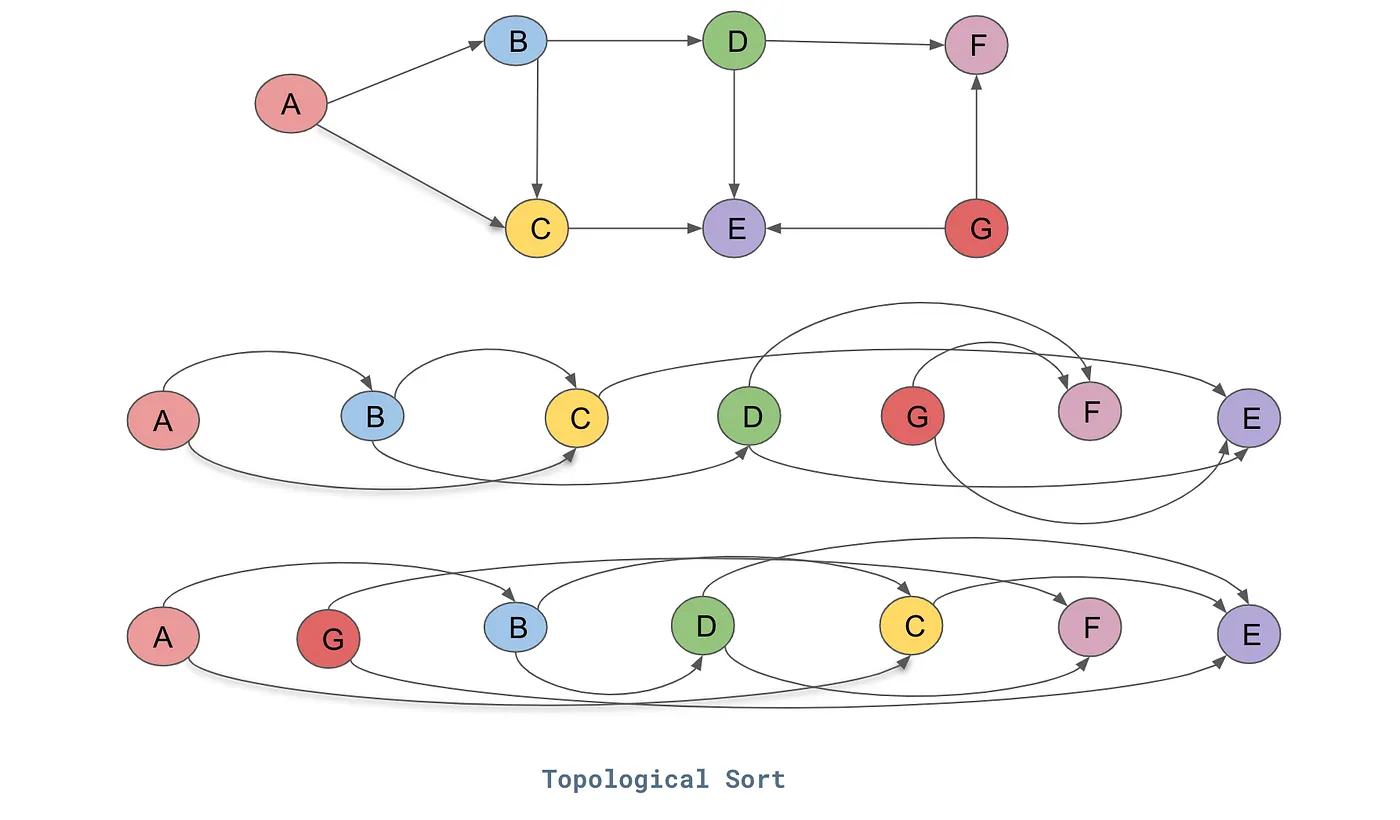

实现和详细说明见：[拓扑排序](https://zhuanlan.zhihu.com/p/659034288)

In [31]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)
# 很明显，之前构建前向计算的计算过程时，就是从左到右的且满足有向无环图(DAG)，所以 v._prev() 就直接保证了节点是从左到右的
# 直接和 draw_dot一样，把所有节点倒着从o遍历一遍即可
print(topo)

# 逆序遍历，因为执行backward需要倒着
for node in topo[::-1]:
    print(node.label)

[Value(data=-3.0), Value(data=2.0), Value(data=-6.0), Value(data=1.0), Value(data=0.0), Value(data=0.0), Value(data=-6.0), Value(data=6.881373587019543), Value(data=0.8813735870195432), Value(data=0.7071067811865476)]
o
n
b
x1w1 + x2w2
x2*w2
x2
w2
x1*w1
x1
w1


In [17]:
from a_utils import draw_dot
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

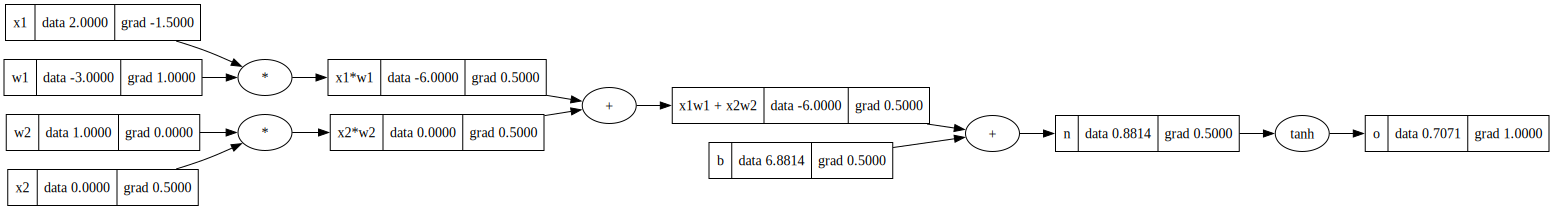

In [22]:
o.grad = 1
for node in topo[::-1]:
    node._backward()
draw_dot(o)

## u8-自动调用的反向梯度

In [32]:
import math
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        self.data = data
        self.grad = 0  
        self._backward = lambda:None 
        self._prev = set(_children)  
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad = 1.0*out.grad
            other.grad = self.grad
        out._backward = _backward 
        return out
        
    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward =  _backward
        return out
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad = (1 - t**2)*out.grad
        out._backward = _backward
        return out
        
    def backward(self):
        """
        只需要对计算图的最后一个节点调用即可
        """
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1
        for node in topo[::-1]:
            node._backward()

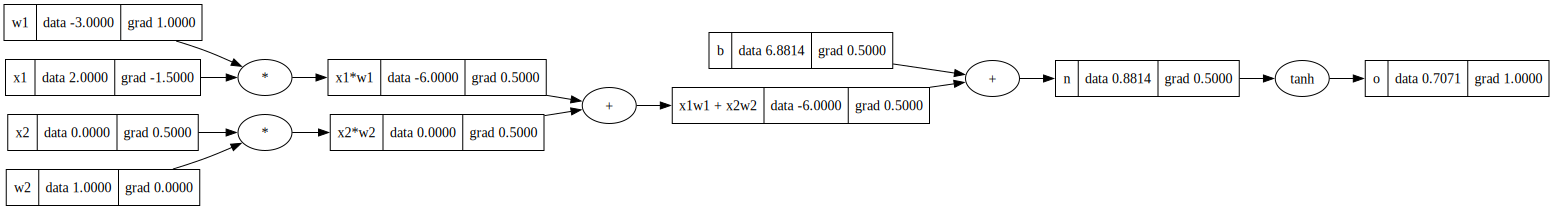

In [33]:
from a_utils import draw_dot
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()
draw_dot(o)

就类似于 ： loss.backward()
+ https://www.geeksforgeeks.org/deep-learning/pytorch-connection-between-lossbackward-and-optimizerstep/
    ```python
        for epoch in range(100):
            optimizer.zero_grad()          
            outputs = model(X_train)        
            loss = criterion(outputs, y_train)    
            loss.backward() # 从最后一个节点，开始计算梯度
            optimizer.step()# 算完梯度后，优化器开始用梯度更新参数权重
            if (epoch + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")
    ```

## 遗漏的bugs（同名变量前向多次出现会导致反向时梯度计算错误）

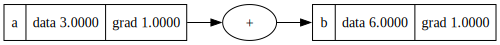

In [34]:
a = Value(3.0, label = 'a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

这里的梯度计算不正确， db/da = 2

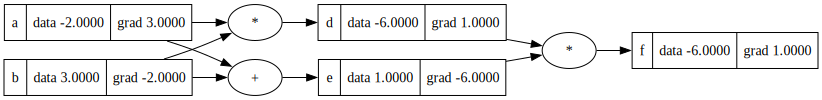

In [36]:
a = Value(-2.0, label='a')
b = Value(3.0,label='b')
d = a * b; d.label='d';
e = a + b; e.label='e'; 
f = d * e; f.label='f';
f.backward()
draw_dot(f)

很明显，这里的梯度计算也是错误的。

dd/da = 3; de/da=-6; 加在一起，df/da = -3

所以但凡计算中重复使用了同一个变量，这个变量的梯度在多次计算中就不会累加，而是被最后一个计算覆盖

## u9-梯度从赋值变成累加

如果计算过程中，有一个变量同时被多个变量引用，即：存在多个中间的因变量，使用了相同的自变量，则可以参考：

**链式法则在多元情况下的形式和推广**

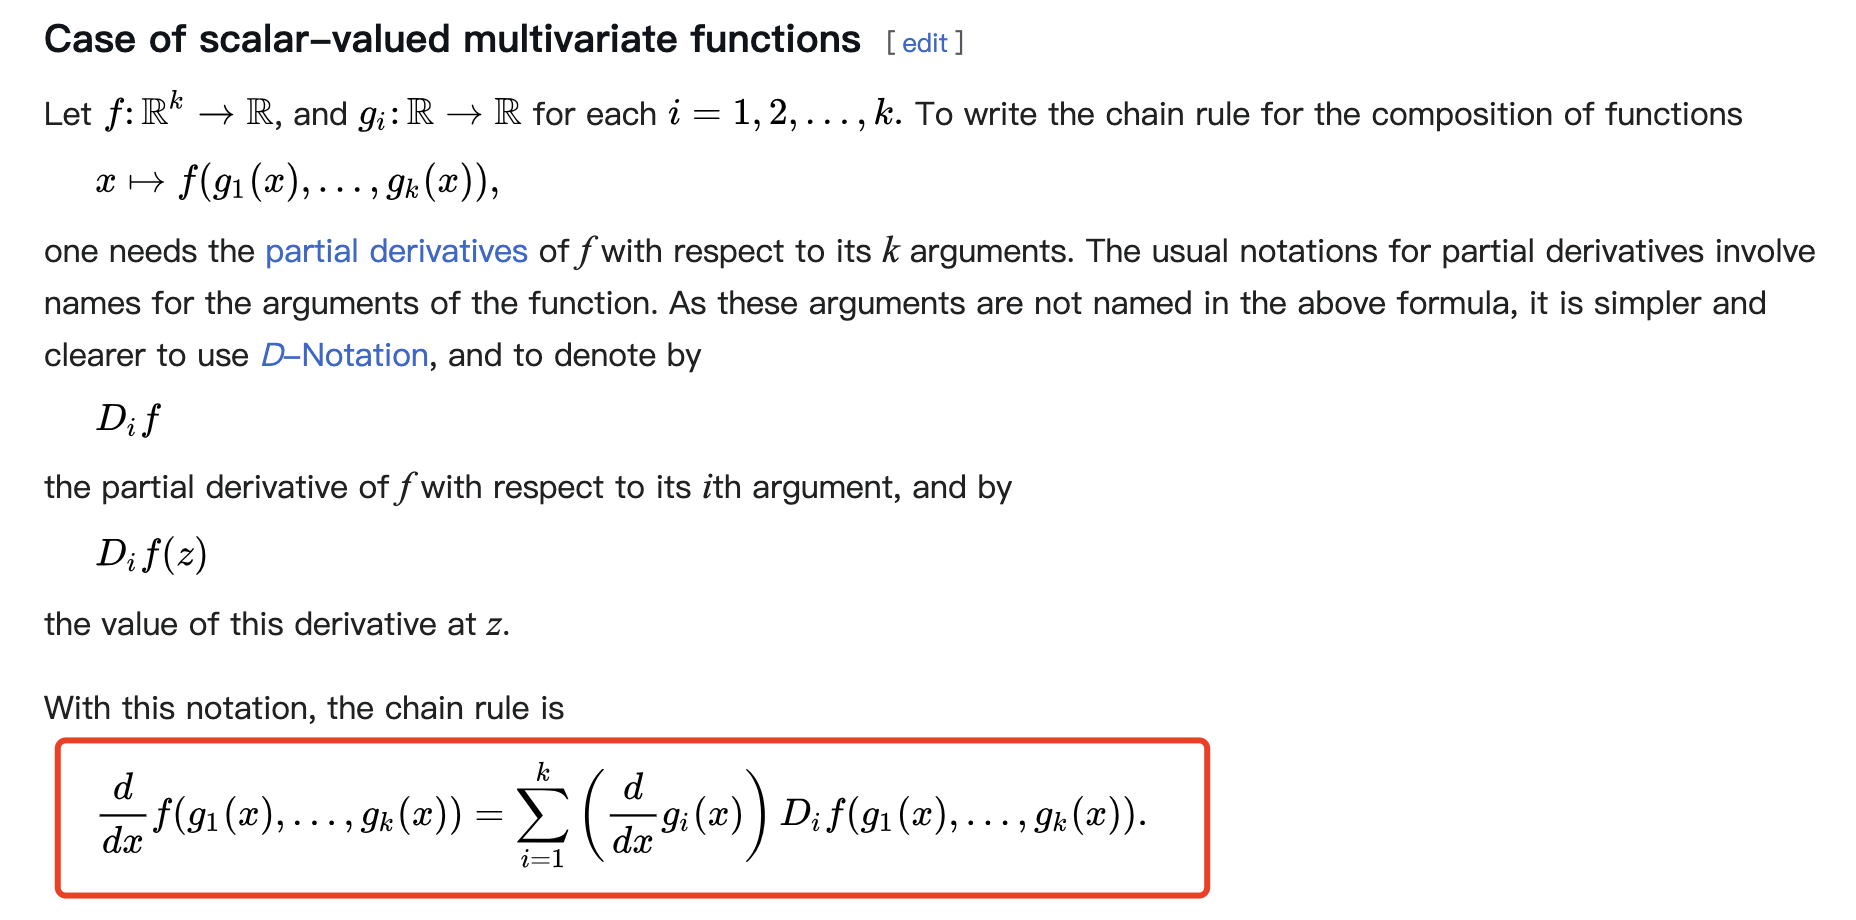

In [37]:
import math
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        self.data = data
        self.grad = 0  
        self._backward = lambda:None 
        self._prev = set(_children)  
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad +=1.0*out.grad
            other.grad += self.grad
        out._backward = _backward 
        return out
        
    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward =  _backward
        return out
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2)*out.grad
        out._backward = _backward
        return out
        
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1
        for node in topo[::-1]:
            node._backward()

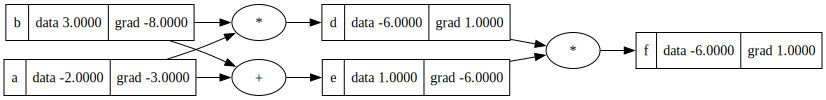

In [38]:
a = Value(-2.0, label='a')
b = Value(3.0,label='b')
d = a * b; d.label='d';
e = a + b; e.label='e'; 
f = d * e; f.label='f';
f.backward()
draw_dot(f)

所以这里可以发现，由于梯度在反向传播过程中被改为了累加，所以正确的初始化就显得很重要。

这里默认初始化是0

+ https://www.geeksforgeeks.org/deep-learning/pytorch-connection-between-lossbackward-and-optimizerstep/
    ```python
        for epoch in range(100):
            optimizer.zero_grad() # optimizer.zero_grad() 的核心作用是：将模型中所有可训练参数的梯度（gradients）清零。       
            outputs = model(X_train)        
            loss = criterion(outputs, y_train)    
            loss.backward()   # 从最后一个节点，开始计算梯度
            optimizer.step()  # 算完梯度后，优化器开始用梯度更新参数权重
            if (epoch + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")
    ```
+ PyTorch 的默认设计是梯度累加（Gradient Accumulation）。当你调用 loss.backward() 进行反向传播时，计算出的新梯度会累加到参数现有的 .grad 属性上，而不是直接覆盖它。
+ 如果不手动清零，每个批次（batch）计算出的梯度会不断叠加。这会导致：
   + 梯度值越来越大（梯度爆炸）。
   + 参数更新的方向完全错误。
   +  模型无法正常收敛，甚至直接崩溃（NaN）。
+ `optimizer.zero_grad()`， 通常放在每一次迭代（iteration）的最开始，或者 `loss.backward()` 之前

## u10-可以与其他非value类的变量进行操作+补充常见操作

In [28]:
import math
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        self.data = data
        self.grad = 0  
        self._backward = lambda:None 
        self._prev = set(_children)  
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __add__(self,other):
        # 对于非Value对象，这里包装成为Value对象
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad +=1.0*out.grad
            other.grad += self.grad
        out._backward = _backward 
        return out

    def __radd__(self,other):
        return self+other
    
    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward =  _backward
        return out

    def __rmul__(self,other):
        """如果遇到 2*Value(2.0), 如果发现无法计算，则会调用 rmul，
            当python遇到 a*b的时候，会按照以下顺序处理
            1. 首先调用a.__mul__(b)
            2. 如果a没有 __mul__方法，或者 a.__mul__(b)返回不支持类的提示，则python接下来会尝试调用 b.__rmul__(a)
        """
        return self*other

    def __pow__(self,other):
        assert isinstance(other, (int,float))
        out = Value(self.data**other, (self,),f'**{other}')
        def _backward():
            self.grad += other * self.data**(other-1) * out.grad
        out._backward = _backward
        return out
        
    def __truediv__(self,other):
        """a/b = a *(1/b) = a* (b**-1)
        在 Python 中，__truediv__ 是一个特殊方法（魔术方法），用于实现真除法（True Division） 运算符 /。
        当你的对象位于 / 运算符的左侧时（例如 a/b），Python 就会调用这个对象的 __truediv__ 方法。
        当python遇到 a/b的时候，会按照以下顺序处理(类似a*b)
        1. 首先尝试调用 a.__truediv__(b),如果 a 没有实现 __truediv__，或者该方法返回了 NotImplemented，
        2. Python 会退而求其次，尝试调用 b.__rtruediv__(a)（即右侧对象的反射除法）。
        这里对value定义了** 幂次
        """
        return self*other**(-1)

    def __neg__(self):  # -self
        return self*(-1)

    def __sub__(self,other):
        return self + (-other)
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,),'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2)*out.grad
        out._backward = _backward
        return out
        
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1
        for node in topo[::-1]:
            node._backward()

In [29]:
a = Value(2.0)
print(a*1)  # 实际执行的是 a.__add__(1)
print(1*a) # 实际执行的是 1.__add__(a), 所以会报错,需要定义 __rmul__
a.exp()

b = Value(4.0)
print(a/b)
print(a-b)

Value(data=2.0)
Value(data=2.0)
Value(data=0.5)
Value(data=-2.0)


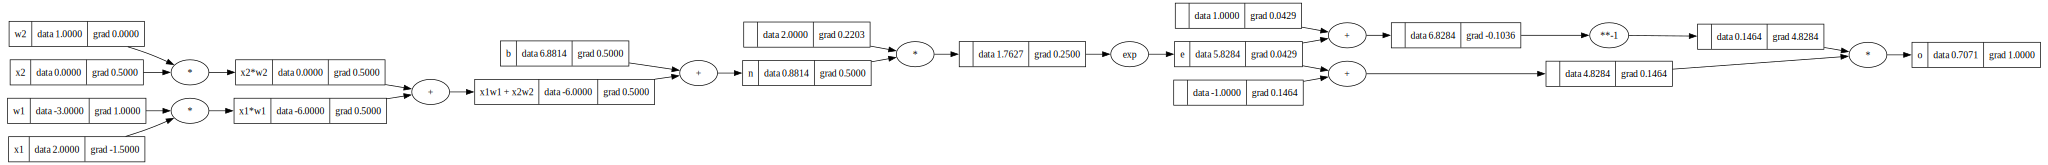

In [30]:
from a_utils import draw_dot
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# o = n.tanh(); 
# 把tanh操作替换成上面实现的幂次和减法以及除法的组合
e = (2*n).exp(); e.label = 'e'
o = (e - 1)/(e + 1)
o.label = 'o'
o.backward()
draw_dot(o)

结果：
1. 计算图变长
2. 前向计算结果和反向梯度完全一致

# 5. pytorch实现上面的流程

```python
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); 
```

In [34]:
import torch
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
# 由于以上都是叶节点，pytorch默认不需要计算梯度，所以需要额外指定需要梯度
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item()) # item,提取张量中的数值
# Docstring:
# item() -> number

# Returns the value of this tensor as a standard Python number. This only works
# for tensors with one element. For other cases, see :meth:`~Tensor.tolist`.

# This operation is not differentiable.
o.backward()
print('-'*5)
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
-----
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


+ 使用 PyTorch 的 API（如 `torch.tensor()`, `torch.zeros()`, `torch.randn()` 等）手动创建一个全新的张量时，它的 `requires_grad` 属性默认是 `False`
+ PyTorch 规定，只有浮点型（如 `float32`, `float64`）和复数型（如 `complex64`）的张量才能开启梯度计算。 如果你尝试为整数型（`int`）或布尔型（`bool`）张量开启梯度，PyTorch 会直接报错。
+ PyTorch 规定：只要参与运算的张量中，有一个张量的 `requires_grad=True`，那么运算得到的结果张量的 `requires_grad`也会自动变成 `True`。
+ 如果你定义的张量是作为神经网络层的权重或偏置，通常会将其包装为 `nn.Parameter`。 规定：`nn.Parameter` 包装的张量，默认 `requires_grad=True`。


即使张量参与了梯度计算，PyTorch 对**梯度值**（`.grad`）的保存位置也有严格规定：
+ **叶子节点（Leaf Tensor）**：用户直接创建的、且 `requires_grad=True` 的张量。反向传播（`.backward()`）后，梯度会自动累加保存在叶子节点的 .grad 属性中。
+ **非叶子节点（中间计算结果）**：通过运算得到的张量。为了节省内存，反向传播后**默认会丢弃它们的梯度**（`.grad 为 None`）。如果非要保留，必须显式调用 `.retain_grad()`。

# 6. 两层的多层感知机实现

会**按照pytorch 的API规范来设计一个神经网络模块**，就**类似上面自动微分部分实现的和python API差不多的样子**（比如： backward()函数）

## 6.1 基本组件

from a_utils import Value
import random
class Neuron:
    def __init__(self, nin):
        """
        初始化函数， nin表示 neuron in,即：神经元接受的输入个数，
        即wx相乘的时候，每个x的维度
        """
        self.w = [Value(random.uniform(-1,1), label='w_') for _ in range(nin)]
        self.b = Value(random.uniform(-1,1), label = 'b')

    def __call__(self,x):
        """
        x就是输入的数据
        x = [2.0, 3.0]
        n = Neuron(2)
        n(x) # 这里会自动调用 __call__方法
        
        如果一个类定义了 __call__ 方法，那么这个类的实例对象就可以像函数一样被直接调用（加上括号 ()）。
        当你调用一个实例对象，并在后面加上括号 () 时，Python 会自动触发该对象的 __call__ 方法。

        __init__ 实例化对象时自动调用（即 obj = MyClass()）每个实例生命周期内通常只调用一次
        __call__ 调用实例对象时自动调用（即 obj()）可以被调用无数次
        """
        # activation 激活值
        # act = sum(wi*xi for wi,xi in zip(self.w, x)) + self.b
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        # Signature: sum(iterable, /, start=0)
        # Docstring:
        # Return the sum of a 'start' value (default: 0) plus an iterable of numbers
        # 在 Python 中，sum() 函数可以接收两个参数：sum(iterable, start)。
        # 第一个参数是可迭代对象（你的生成器表达式）。
        # 第二个参数是求和的初始值（你的 self.b）。
        # 语法规则规定：如果生成器表达式是函数的唯一参数，可以省略外层括号（例如 sum(x for x in y)）；但如果函数有多个参数，生成器表达式必须用括号括起来，否则 Python 解析器无法区分逗号是属于生成器内部的，还是用来分隔函数参数的。
        out = act.tanh() # 返回经过非线性处理后的激活值
        return out


x = [2.0, 3.0]
n = Neuron(2)
n(x)

单个神经元定义好了，就可以去定义层了(回到之前看过的例子)

<img src="https://cs231n.github.io/assets/nn1/neuron_model.jpeg" width=40%>
<img src="https://cs231n.github.io/assets/nn1/neural_net2.jpeg" width=40%> 

In [2]:
class Layer:
    def __init__(self, nin, nout):
        """
        nin: 当前层的输入的维度/标量个数
        nout: 当前层的输出的维度/变量个数
        """
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs  
        # 如果是output层,一般后面要跟着计算损失函数,所以方便起见,这里直接长度为1时返回准确的值,而不是列表

# 以上面的 hidden layer1为例， nin = 3， 承接3个输入节点； nout=4，承接后面的4个神经元
# x = [1.0,2,0,3.0]
# l1 = Layer(3,4)
# l1(x)
# 这里返回了4个值，
# [Value(data=-0.9544887784366052),
# Value(data=0.6217435256899618),
# Value(data=-0.45743424837000274),
# Value(data=0.404147052205695)]
# outs = [n(x) for n in  [Neuron(nin) for _ in range(nout)]]
# 所以实际上，是对 x 执行 n(x), 和上面的例子一样
# 是4个神经元各自独立完成上面的 n(x)的计算
# 相当于这层有 4个神经元，每个神经元有 w1,w2,w2个标量权重，所以一共是12个待更新的权重参数
# l1(x)输出四个值之后，l2(x)也是接受4个输出四个，l2这层是16个标量权重参数

In [3]:
class MLP:
    def __init__(self,nin,nouts):
        """
        nin: 输入层的维度/标量个数（即MLP中和输入层挨着的 第一个权重层 单个神经元的权重的标量个数）
        nouts: 其余所有权重层的输出的维度/变量个数，是个列表
        """
        sz = [nin] + nouts  # 列表拼接 [9] + [10,11] = [9, 10, 11]
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(sz)-1)] #或者简单点，直接写 range(len(nouts))
        # 这个创建方式就保证了层之间维度的连续性
        #  [3,4,4,1]→(3*4, 4*4,4*1)

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x

In [4]:
x = [2.0, 3.0, -1.0]
n = MLP(3,[4,4,1])
n(x)  

Value(data=-0.86331840034335)

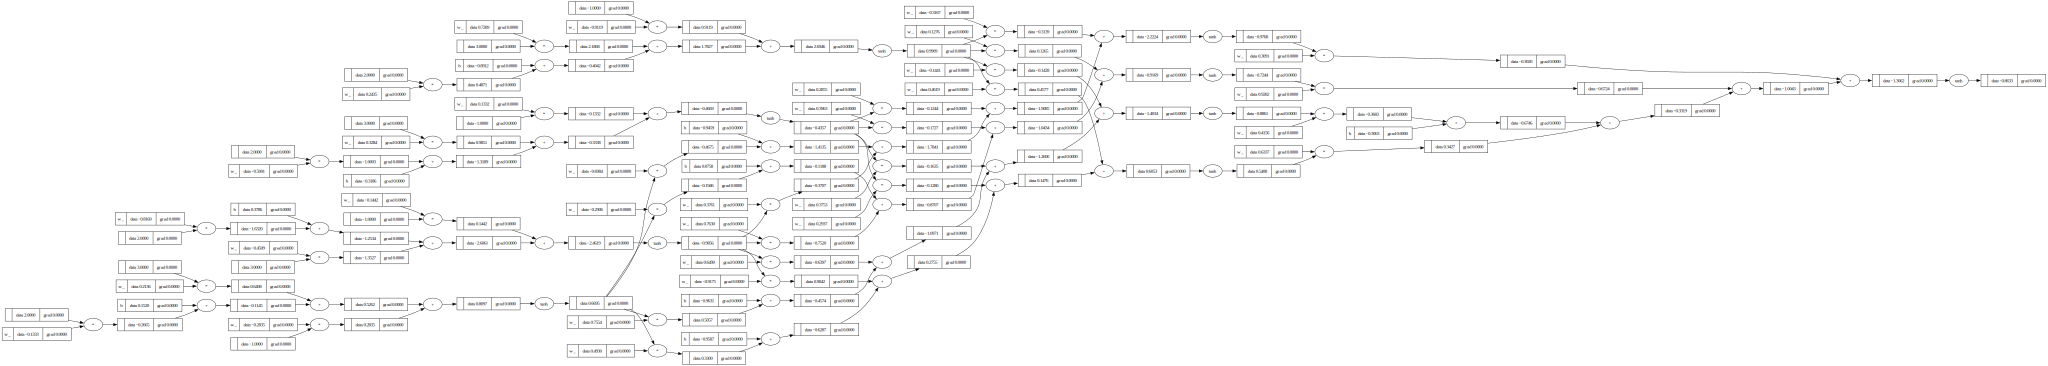

In [5]:
from a_utils import draw_dot
draw_dot(n(x))

可以仔细看一下这个图(在上面补充了一下label，只能补充 w和b的)：
1. 最左边的四个叶子节点，都是`权重` 和 `x里的数据 2.0`**相乘**的结果
2. 下一步，可以看到有个乘法节点，是 `权重` 和 `x里的数据 3.0`**相乘**的结果
3. 再一步，可以看到有个乘法节点，是 `权重` 和 `x里的数据 -1.0`**相乘**的结果
4. 截止到tanh，才是一层的 wixi+b实现完了，只是因为 `w1 * x1 + w2 * x2 + w3 * x3 + b`(三个乘法和三个加法，数最下面那个好数)，同时要分步相加，操作比较多，所以整个计算图就非常大

只能看第一层，到第二层就太费劲了。。。

```python
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); 
o.backward()
```


注意, 之前的例子里直接对`o`进行反向传播, 是直接把o的值当成损失函数的值了,即把`o`的值作为 `y_pred-y_true`来计算了, 但是下面举的例子才是真实的损失函数的情况,上面只是示例


In [6]:
# 简单的示例数据
# x_sample
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
     ]
# y_sample 二分类任务
ys = [1.0, -1.0, -1.0, 1.0]

ypred = [n(x)  for x in xs]
ypred

[Value(data=-0.86331840034335),
 Value(data=-0.9721877517430506),
 Value(data=-0.939683183530971),
 Value(data=-0.9010171254353754)]

很明显，如果直接用随机初始化的权重来进行计算，得到的`ypred`会与真实的`y`值差距很明显
+ 这里需要 第一个y（因变量）的值增大，即：之前的权重 要朝着梯度方向变化
+ 后续三个都需要变得更小，变成-1，即之前的权重 要朝着梯度的方向变化
+ 为了协调多个样本, 让梯度变化可以最大程度上协调所有样本，这里就会引入一个 **损失函数**
  + **损失函数**最终的体现结果其实就是一个标量数值,用这个数值来衡量整个网络对样本的描述能力
  + 这里作为demo,采用最常见的 `均方误差损失`(`mean squared error loss`)


```bash
# 随机初始化w得到 n(x)得到的y值
[Value(data=-0.86331840034335),
 Value(data=-0.9721877517430506),
 Value(data=-0.939683183530971),
 Value(data=-0.9010171254353754)]
```

In [7]:
[(ygt - yout)**2 for ygt, yout in zip(ys, ypred)]
# TypeError: unsupported operand type(s) for -: 'float' and 'Value'
# 把Value也加一个 __rsub__

[Value(data=3.471955461058101),
 Value(data=0.0007735211531061844),
 Value(data=0.0036381183489585254),
 Value(data=3.6138661111985777)]

In [12]:
for ygt, yout in zip(ys,ypred):
    print(f"真值: {ygt}, 预测值: {yout.data}, 直接差值: {(ygt - yout).data}, 差值平方后: {((ygt - yout)**2).data}")

真值: 1.0, 预测值: -0.86331840034335, 直接差值: -1.86331840034335, 差值平方后: 3.471955461058101
真值: -1.0, 预测值: -0.9721877517430506, 直接差值: 0.02781224825694939, 差值平方后: 0.0007735211531061844
真值: -1.0, 预测值: -0.939683183530971, 直接差值: 0.06031681646902898, 差值平方后: 0.0036381183489585254
真值: 1.0, 预测值: -0.9010171254353754, 直接差值: -1.9010171254353754, 差值平方后: 3.6138661111985777


很明显，对于二次函数来说，
+ $x<1, x^2(y) < x$
+ $x>1, x^2(y) >> x$

所以**当真值和预测值很接近的时候，损失很小；而不太接近的时候，损失则会被放的很大**

如果单纯只是为了消除符号的影响，那么**除了平方之外，也可以直接取绝对值**

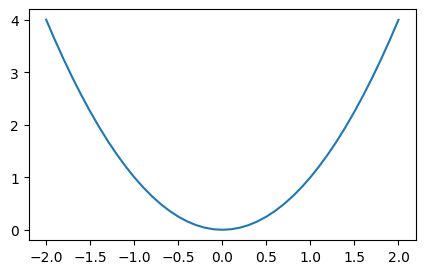

In [18]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(5,3))
plot_x = np.arange(-2,2.1,0.1)
plot_y = plot_x**2
plt.plot(plot_x,plot_y)

In [19]:
loss = sum((ygt - yout)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.090233211758743)

## 6.2 完整结果

In [1]:
from a_utils import Value
import random
import matplotlib.pyplot as plt

# 精简点, 统一放在一起其实很短
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1), label='w_') for _ in range(nin)]
        self.b = Value(random.uniform(-1,1), label = 'b')

    def __call__(self,x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        out = act.tanh() 
        return out

    def parameters(self):
        # 这个函数命名是为了和pytorch保持一致 pytorch也是每个模块都有这个函数
        return self.w + [self.b]
    
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs  
    
    def parameters(self):
        # 这里不区分 w和b，只要是需要更新的参数，都放进去，可以区分的唯一方法大概就是提前命名的label了
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # 嵌套列表生成式
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extend(ps)
        # return params

class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts  
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] 

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
        
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        # params = []
        # for layer in self.layers:|
        #     ps = layer.parameters()|
        #     params.extend(ps)
        # return params

In [12]:
# draw_dot(loss)

# 画出来依然很复杂，但是这里可以看出来，每个节点都有梯度值了~
# 包括输入数据，也有梯度值，但是输入数据是不能修改的，所以输入数据的梯度值，没啥作用

In [13]:
n = MLP(3,[4,4,1])
len(n.parameters())
#  = (3+1)*4 + (4+1)*4 + (4+1)*1 = 16 + 20 +5 = 41
# (3+1)是三个w + 1个b的意思， (4+1)同理

41

In [14]:
# 简单的示例数据
# x_sample
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
     ]
# y_sample 二分类任务
ys = [1.0, -1.0, -1.0, 1.0]

In [4]:
ypred = [n(x) for x in xs]

loss_list = []
loss = sum((yout - ygt)**2 for yout, ygt in zip(ypred, ys))
loss_list.append(loss)
print(loss)
loss.backward()

Value(data=7.613210049092068)


In [5]:
n.layers[0].neurons[0].w[0].grad  # -2.998608961773418
# MLP的初始化函数里， 有 self.layers
# Layer的初始化函数里，有 self.neurons
# Neuron的初始化函数里，有 self.w
# 注意，这里的layers[0] 其实是  Layer(sz[i], sz[i+1]) = Layer(3,4) 即：有4个神经元，每个神经元有3个变量wi

# 梯度更新了，默认创建的时候 grad都是0
# 这里算出来的梯度为负值，之前说过，沿着梯度方向是函数增加最快的方向(权重+梯度)
# 但是现在不要求函数增加，而是要求函数减少，所以需要和梯度反方向(权重 - 梯度)

1.4266703519066302

In [6]:
n.layers[0].neurons[0].w[0].grad,  n.layers[0].neurons[0].w[0].data

(1.4266703519066302, -0.87101951941953)

In [7]:
# 对所有可变的 能控制最终结果的参数， 根据梯度进行权重/参数值更新
for p in n.parameters():
    p.data -= 0.01 * p.grad

In [8]:
n.layers[0].neurons[0].w[0].data  # 梯度更新后，权重的数值发生了小的变化

-0.8852862229385964

In [9]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for yout, ygt in zip(ypred, ys))
loss_list.append(loss)
print(loss)

Value(data=7.545126034698599)


可以看到，更新一次参数后，损失从 `Value(data=6.087903364431515)` 降低到了 `Value(data=5.55864339094799)`

**不断重复**下面这个梯度更新的过程（会看到损失有时候会波动）

In [4]:
loss_list = []

[Value(data=-0.9439100582108565), Value(data=-0.9439101875244797), Value(data=-0.9435529134326796), Value(data=-0.9438928435294303)]
Value(data=7.563838042183747)


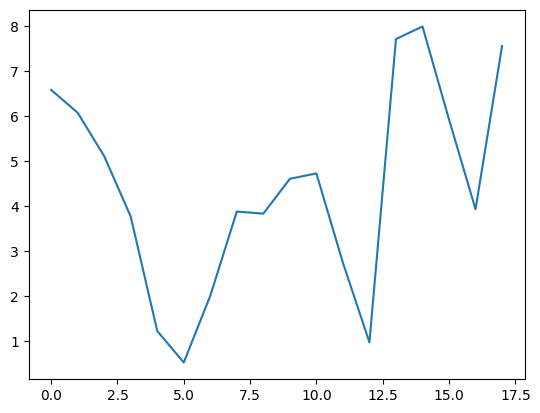

In [22]:
ypred = [n(x) for x in xs]
print(ypred)
loss = sum((yout - ygt)**2 for yout, ygt in zip(ypred, ys))
print(loss)
loss_list.append(loss.data)
plt.plot(list(range(len(loss_list))), loss_list)
loss.backward()

for p in n.parameters():
    p.data-=0.01 * p.grad

...这里随机性超级强。。。而且经常错过最优点，越跑越离谱
+ 每次损失增加的时候，就把梯度改成`p.data+=0.01 * p.grad`， 跑两次，再改回为`-`   ⬅️ 观察到这个现象就是因为grad没有清零
+ 依然是个玄学。。。
+ 上面错误的原因是因为：
    + 每次反向传播和更新参数后，在下一次反向传播之前，没有把每个参数的grad重置为0，导致grad一直在累加，所以一直错。。。
    + 所以跟视频教程的结果一直不一样。。。

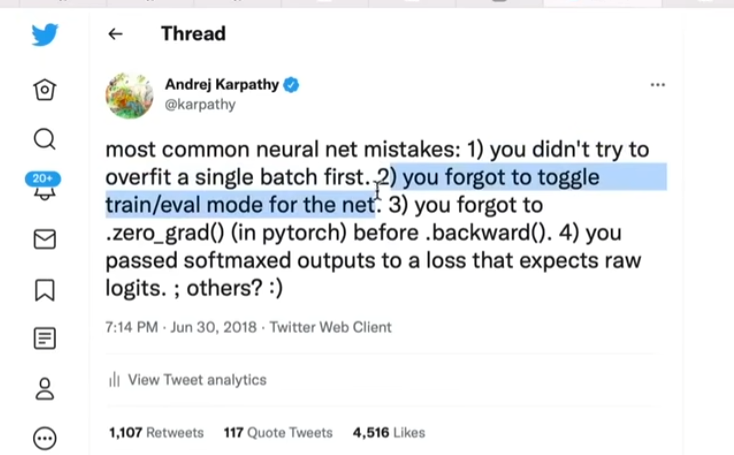

改成常见的 for step或者for epoch的那种**循环训练**的格式

In [9]:
# seed = 732
# random.seed(seed)

n = MLP(3,[4,4,1])
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
     ]
# y_sample 二分类任务
ys = [1.0, -1.0, -1.0, 1.0]

for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for yout, ygt in zip(ypred, ys))

    # backward pass
    # for p in n.parameters():
    #     p.grad = 0.0  # 每次记得要清零 一般是放在 backward之前
    loss.backward()
    for p in n.parameters():
        p.data -=0.2 * p.grad
        p.grad = 0.0  # 但是由于第一次的时候就是0,所以放在这里执行其实效果是一样的
        
    print(f'current step: {k}, loss: {loss.data}')
print(ypred)

current step: 0, loss: 6.592580673818207
current step: 1, loss: 3.8235821278686903
current step: 2, loss: 4.073717512095748
current step: 3, loss: 5.865086798304037
current step: 4, loss: 1.792357740502776
current step: 5, loss: 0.11061511907670094
current step: 6, loss: 0.0027244756749736166
current step: 7, loss: 0.002606557132775098
current step: 8, loss: 0.0024979539611803448
current step: 9, loss: 0.002398030196146559
current step: 10, loss: 0.0023279838897172895
current step: 11, loss: 0.002259583619525361
current step: 12, loss: 0.002182075172899529
current step: 13, loss: 0.0021107451211831102
current step: 14, loss: 0.0020448222909573753
current step: 15, loss: 0.0019935654532541314
current step: 16, loss: 0.001935805194887335
current step: 17, loss: 0.0018808825398408742
current step: 18, loss: 0.001840048215409834
current step: 19, loss: 0.001792308590276413
[Value(data=0.9758420921235107), Value(data=-0.9894308900556863), Value(data=-0.9915500365773501), Value(data=0.967975

# 7. 额外说明（pytorch的tanh实现）

直接在pytorch源码里找不到，通过一个帖子： [Change the tanh backward code](https://discuss.pytorch.org/t/change-the-tanh-backward-code/148609/3)
+ [pytorch/aten/src/ATen/native/cuda/BinaryMiscBackwardOpsKernels.cu](https://github.com/pytorch/pytorch/blob/a0a2b755659a0fd0e12d209ac84c402538a75e1b/aten/src/ATen/native/cuda/BinaryMiscBackwardOpsKernels.cu#L86-L100)
+ [pytorch/aten/src/ATen/native/cpu/BinaryOpsKernel.cpp](https://github.com/pytorch/pytorch/blob/c5872e6d6d8fd9b8439b914c143d49488335f573/aten/src/ATen/native/cpu/BinaryOpsKernel.cpp#L793-L836)